# Table of Content <a id='toc'></a>


&nbsp;&nbsp;&nbsp;&nbsp;[1. probability distributions](#0)

&nbsp;&nbsp;&nbsp;&nbsp;[Exercise 01](#1)

&nbsp;&nbsp;&nbsp;&nbsp;[Exercise 02](#2)

&nbsp;&nbsp;&nbsp;&nbsp;[2. Statistical hypothesis testing](#3)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[2.1 t-test : difference between two means](#4)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[2.2 t-test assumptions and what to do when they are not respected](#5)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[2.2.1 testing normality](#6)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[2.2.2 nonparametric testing : Mann–Whitney U test](#7)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[2.3 p-value, power and errors](#8)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[2.3.1 errors of type I and II](#9)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[2.3.2 P-values](#10)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[2.3.3 power](#11)

&nbsp;&nbsp;&nbsp;&nbsp;[Exercise 03](#12)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[2.4 BONUS : multiple testing](#13)


[back to the toc](#toc)

<br>

# 1. probability distributions  <a id='0'></a>


In [2]:
import matplotlib.pyplot as plt
from IPython.display import Image
import seaborn as sns
import scipy.stats as stats 
import pandas as pd
import numpy as np


### This is some configuration to make the plots work better when presenting online
%matplotlib inline

import matplotlib.pylab as pylab
pylab.rcParams['figure.figsize'] = 10, 10
plt.rc("font", size=16)


## Small definitions
### what is a random variable ?

A *variable* is a value that can change. We usually represent them as letters (e.g., x, y, a).

A *random variable* is a variable whose value depends on the outcome of a random experiment. They are usually defined by capital letters (e.g., X,Y,Z).

---
For example, consider the experiment of tossing a coin.

&nbsp;&nbsp;&nbsp;&nbsp;We define a random variable X as follows:

> &nbsp;&nbsp;&nbsp;&nbsp; \(X = 1\) if the result is Heads  
> &nbsp;&nbsp;&nbsp;&nbsp; \(X = 0\) if the result is Tails  

&nbsp;&nbsp;&nbsp;&nbsp;After performing the experiment, the random variable X takes a specific value depending on the observed outcome.




### what is a probability distribution ?

A probability distribution represents the different values that a *random variable* might take and associates a specific probability to each of them.


They are commonly represented using **Probability Mass Function (pmf)** for discrete random variables or **Probability Density Function (pdf)** for continuous random variables

In both case, the horizontal axis represents possible values of the random variable, the vertical axis represents probabilities of obtaining these values (discrete) or the density of probability at each value (continuous).  

>*(NB: For continuous random variables, the probability of observing an exact value is 0, because there are infinitely many possible values. That is the reason why the pdf of continuous random variables represents the **"density of probability"** and not the actual **probability**. This density of probability defines how likely it is that the variable falls within a specific range, with the actual probabily calculated as the area under the pdf curve between two points.)*  

An important property of probability distribution is that they sum to 1. 
This is quite apparent when plotting the **cumulative mass (cmf)** and **cumulative density function (cdf)** of a distribution. The vertical axis of the cmf/cdf gives the probability that the variable takes a value less than or equal to the corresponding value on the horizontal axis.  

  


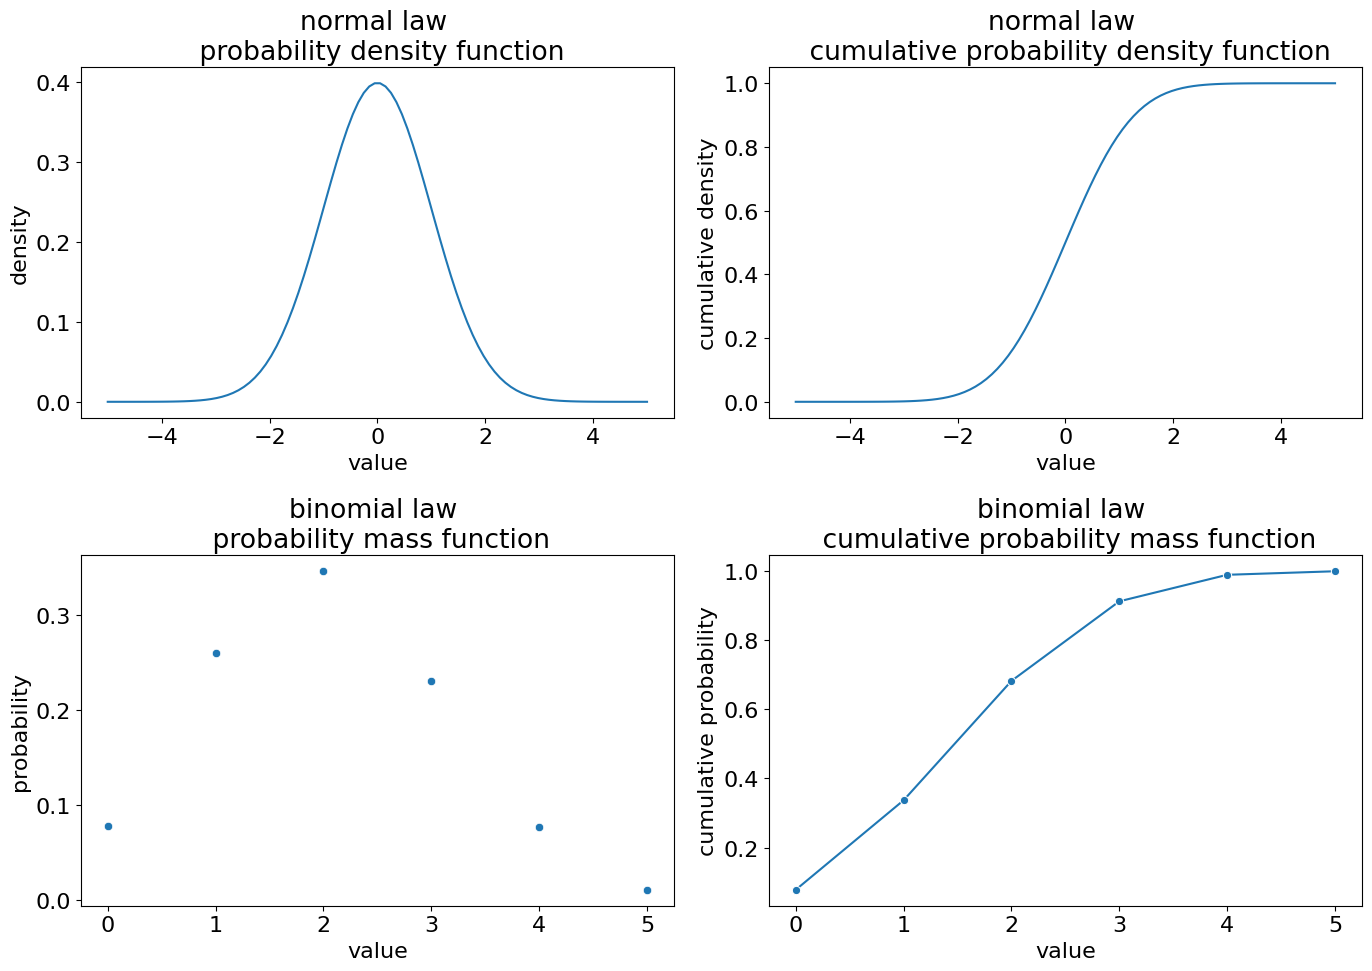

In [3]:
f, axes = plt.subplots( 2, 2, figsize=(14, 10) )                  # Create a 2*2 grid for plotting

# standard normal distribution (continuous)
x = np.linspace(-5,5, 100)                                        # 100 equally separated points between -5 and 5
sns.lineplot(x=x, y=stats.norm.pdf(x) , ax = axes[0,0])           # plot the normal law pdf
axes[0,0].set(xlabel='value', ylabel='density')
axes[0,0].set_title('normal law \n probability density function')
sns.lineplot(x=x, y=stats.norm.cdf(x) , ax = axes[0,1])           # plot the normal law cdf
axes[0,1].set(xlabel='value', ylabel='cumulative density')
axes[0,1].set_title('normal law \n cumulative probability density function')

# binomial distribution (discrete)
n, p = 5, 0.4                                                     # parameters of the binomial distribution (n = number of draws, p = Success probability)
x = list(range(n+1))                                              # all integers from 0 to n, included.
sns.scatterplot(x=x, y=stats.binom.pmf(x,n,p) , ax = axes[1,0])   # plot the binomial law pmf
axes[1,0].set(xlabel='value', ylabel='probability')
axes[1,0].set_title('binomial law \n probability mass function')
sns.lineplot(x=x, y=stats.binom.cdf(x,n,p) , marker="o",  ax = axes[1,1]) # plot the binomial law cmf
axes[1,1].set(xlabel='value', ylabel='cumulative probability' )
axes[1,1].set_title('binomial law \n cumulative probability mass function')

plt.tight_layout()
plt.show()

Most distributions have a certain number of **parameters** which may control their overall **shape, location or scale**.

For Instance the normal law has two parameters : its mean ($\mu$ or $m$) and its standard deviation ($\sigma$ or $s$), which respectively control its location and scale.

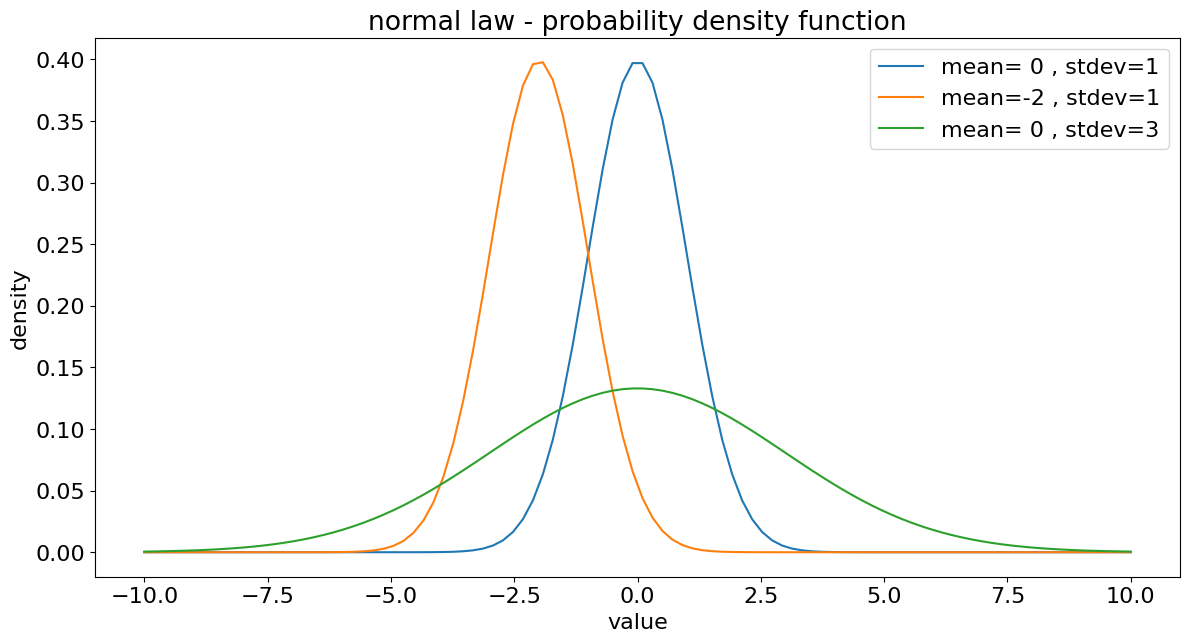

In [4]:
## Plot normal law pdf for different parameters (mean or standard deviation)

x = np.linspace(-10,10, 100) # 100 equally separated points between -10 and 10
fig, ax = plt.subplots(figsize=(14, 7))

## Here loc defines the mean and scale the standard deviation
sns.lineplot(x=x, y=stats.norm.pdf(x , loc = 0 , scale = 1) , ax = ax , label='mean= 0 , stdev=1')
sns.lineplot(x=x, y=stats.norm.pdf(x , loc = -2 , scale = 1 ) , ax = ax , label='mean=-2 , stdev=1')
sns.lineplot(x=x, y=stats.norm.pdf(x , loc = 0 , scale = 3 ) , ax = ax , label='mean= 0 , stdev=3')

## Add title, axis name and legend
ax.set_title('normal law - probability density function')
ax.set(xlabel='value', ylabel='density')
ax.legend()
plt.show()

What is of particular interest to us here is that 
these theoretical **probability distributions can be used to model 
how a particular random variable would behave under a particular hypothesis**.
This prediction can then be compared to data measured in the world.

To signify that a random variable follows a particular distribution, we use the $\sim$ notation. So if variable $X$ follows a normal distribution of mean $m$ and standard deviation $s$, we write:
$$X \sim N(m , s )$$


## why everyone talks about the normal distribution - confidence interval

It is more than likely that you have heard about the normal distribution (or Bell curve / Gaussian) and 95% confidence interval. You may also have, in this context, heard about the value 1.96, or 2 standard deviations. 

This relates to a peculiar (and very convenient) property of random variables :
"In many common situations, if you repeat the same random experiment many times independently and take the average of the results, this average tends to follow a normal distribution. (even if the original data are not normally distributed)" (simplified from [wikipedia](https://en.wikipedia.org/wiki/Illustration_of_the_central_limit_theorem))

This is called the **Central Limit Theorem**, and it applies to large samples (often n $\geq$ 30) of independent and identically distributed random variables. It claims that for large samples, the mean of a sample is a random variable itself whose distribution is (aproximately) normal. Basically, the larger the sample, the better it fits a normal distribution.

Let's demonstrate this on the exponential law, its Probability Density Function is given below (simplified) :
$$
f(x) =  e^{ -x}, \quad x \geq 0
$$


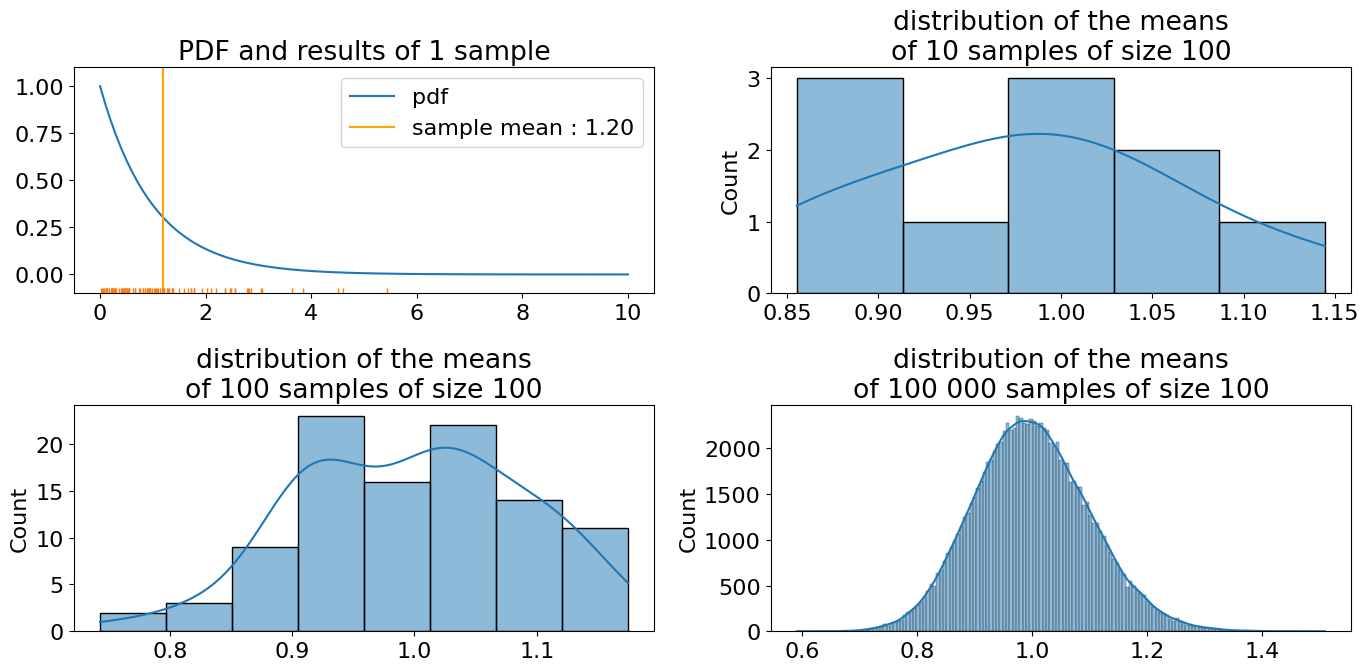

In [5]:
# Say we collect a sample of size 100 in an exponential distribution, and compute the mean of that sample


## Create the sampling function
def sampling(sample_size):
    """
    This function samples sample_size values from an exponential distribution.
    It returns the sample as a np.array.
    """
    
    sample = np.random.exponential(size=sample_size) # numpy function that draws samples from an exponential distribution.
    
    return sample 

## Create the samples 

# Take a large sample size so that the CLT applies
sample_size = 100

# Sample one time
sample1 = sampling(sample_size)

# let's repeat this 10 times, and keep only the mean of each sample
sampled_means_10     = [sampling(sample_size).mean() for i in range(10)]
# now let's repeat this 100 times, and keep only the means
sampled_means_100    = [sampling(sample_size).mean() for i in range(100)]
# now let's repeat this 100 000 times, and keep only the means
sampled_means_100000 = [sampling(sample_size).mean() for i in range(100000)]


## Plotting 
fig, axes = plt.subplots(2,2,figsize=(14, 7))
x = np.linspace(0,10, 100) # Watch probability density between 0 and 10
sns.lineplot(x=x, y=stats.expon.pdf(x) , ax=axes[0,0], label="pdf")
axes[0,0].axvline(sample1.mean() , color='orange', label=f"sample mean : {sample1.mean():.2f}")
sns.rugplot(x=sample1, ax = axes[0,0])
axes[0,0].set_title("PDF and results of 1 sample") # each orange bar correspond to one observation of the random variable
axes[0,0].legend()

sns.histplot(sampled_means_10, kde=True, ax=axes[0,1]) # KDE draws a smooth curve to show the distribution of the data
axes[0,1].set_title(f"distribution of the means\nof 10 samples of size {sample_size}")

sns.histplot(sampled_means_100, kde=True, ax=axes[1,0])
axes[1,0].set_title(f"distribution of the means\nof 100 samples of size {sample_size}")

sns.histplot(sampled_means_100000, kde=True, ax=axes[1,1])
axes[1,1].set_title(f"distribution of the means\nof 100 000 samples of size {sample_size}")

plt.tight_layout()

You can see there that the distribution of the mean looks normal, it appears more clearly when considering a big amount of samples.

## OK, but that is just something you did with simulations, does that work on real data ?

Let's do the same, with the census data. Remember that the census data contains information about the whole population of Switzerland in the year 1880.  
Here we are in the special case were we have the **entire population**, so we know the **population mean**.

By randomly choosing some cities, we produce a **sample mean**. 

Let's take an example by observing the **fraction of foreigners in Swiss towns** :


In [6]:
# Load the census dataframe
df = pd.read_csv( "data/census1880_fractions.csv" )

# The information about the fraction of foreigners in Swiss towns is contained in the "Foreigner" column
print("Census DataFrame :\n", df[["town name","Total","Swiss", "Foreigner"]].head(), "\n")

# Get the true population mean for the whole Switzerland
population_mean = df["Foreigner"].mean() 

# Get the mean across a sample of 100 towns
sample = np.random.choice(df["Foreigner"], size=100) 
sampled_mean = sample.mean() 

# Print results
print("Considering the fraction of foreigners present in Swiss towns :\n")
print(f"    - population mean : {population_mean :.4f}" )
print(f"    - sample mean     : {sampled_mean :.4f}"     )

# Run this code multiple times and observe how the sample mean change 

Census DataFrame :
             town name  Total     Swiss  Foreigner
0              Aeugst    646  0.970588   0.029412
1  Affoltern am Albis   2201  0.948660   0.051340
2          Bonstetten    771  0.977951   0.022049
3              Hausen   1363  0.957447   0.042553
4            Hedingen    907  0.955899   0.044101 

Considering the fraction of foreigners present in Swiss towns :

    - population mean : 0.0408
    - sample mean     : 0.0381


According to the central limit theorem, these sample means are not completely random : they are spread around the population mean according to a normal law.  
**Let's make this distribution appear !**

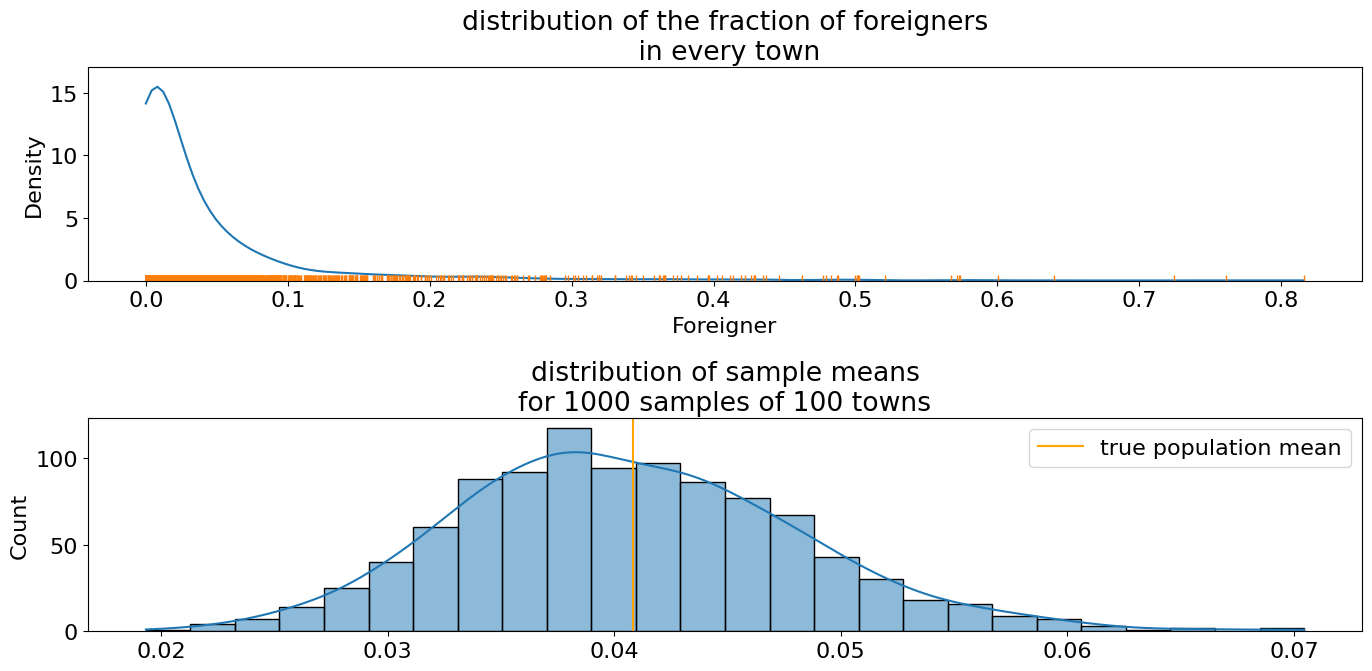

In [7]:
# To make the distribution appear, we create a large number of samples (imagine you have a lot of polls)

sampled_means = [] # We will fill in this list the means of our samples

# Sample 1000 times
n = 1000
for i in range(n):

    sample_size = 100
    sample = np.random.choice(df["Foreigner"], size=sample_size) # Sample the foreigner fraction in the selected number of towns
    sampled_means.append(sample.mean()) 
    
    ## try to change the sample_size : when it is small, the sampled mean is not normally distributed
    ## lower sample size still gets a curve that looks bell-like but you can notice larger variability, weaker symetry and more pronounced tails compared to what we would expect under a perfect normal distribution
    ## as the sample size increases, the sampled mean distribution becomes closer to a normal distribution
    ## This will be presented more in details in the next section


## Plotting 

# Plot the distribution of the fraction of foreigners in every town (i.e. in our whole population)
fig, axes = plt.subplots(2,1,figsize=(14, 7))
x = np.linspace(0,10, 100)
sns.kdeplot(df["Foreigner"], ax=axes[0], cut=0) # KDE plot draws a smooth curve to show the distribution of the data
sns.rugplot(df["Foreigner"] , ax=axes[0]) # Each orange bar corresponds to the fraction of foreigner in one town
axes[0].set_title('distribution of the fraction of foreigners\n in every town')

# Plot the distribution of the sample means, to see if they really are spread around the real population mean according to a normal distribution
sns.histplot(sampled_means, kde=True, ax=axes[1])
axes[1].axvline(population_mean , color='orange', label='true population mean')
axes[1].set_title(f"distribution of sample means\nfor {n} samples of {sample_size} towns")
axes[1].legend()

plt.tight_layout()
plt.show()

We can see here the same things that we observed in our simulations earlier : the distribution of the mean looks normal and centered around the real population mean.      
In the normal law appearing above, according to the CLT :
 * the mean is equal to the **mean of the original distribution**  
 * the standard deviation depends on the **standard deviation of the original distribution divided by the square root of $n$**.

Using the notation we introduced earlier this looks like:

$$\bar{x} \sim N(m , \frac{s}{\sqrt{n}} )$$

where $\bar{x}$ is the **sample mean**, and ${m}$, $s$ are respectively the **mean** and the **standard deviation** of the population. When the sample size $n$ rises, the standard deviation decreases.  

However, note that **this only works if the sample size $n$ is large enough**, let's illustrate this with an example :

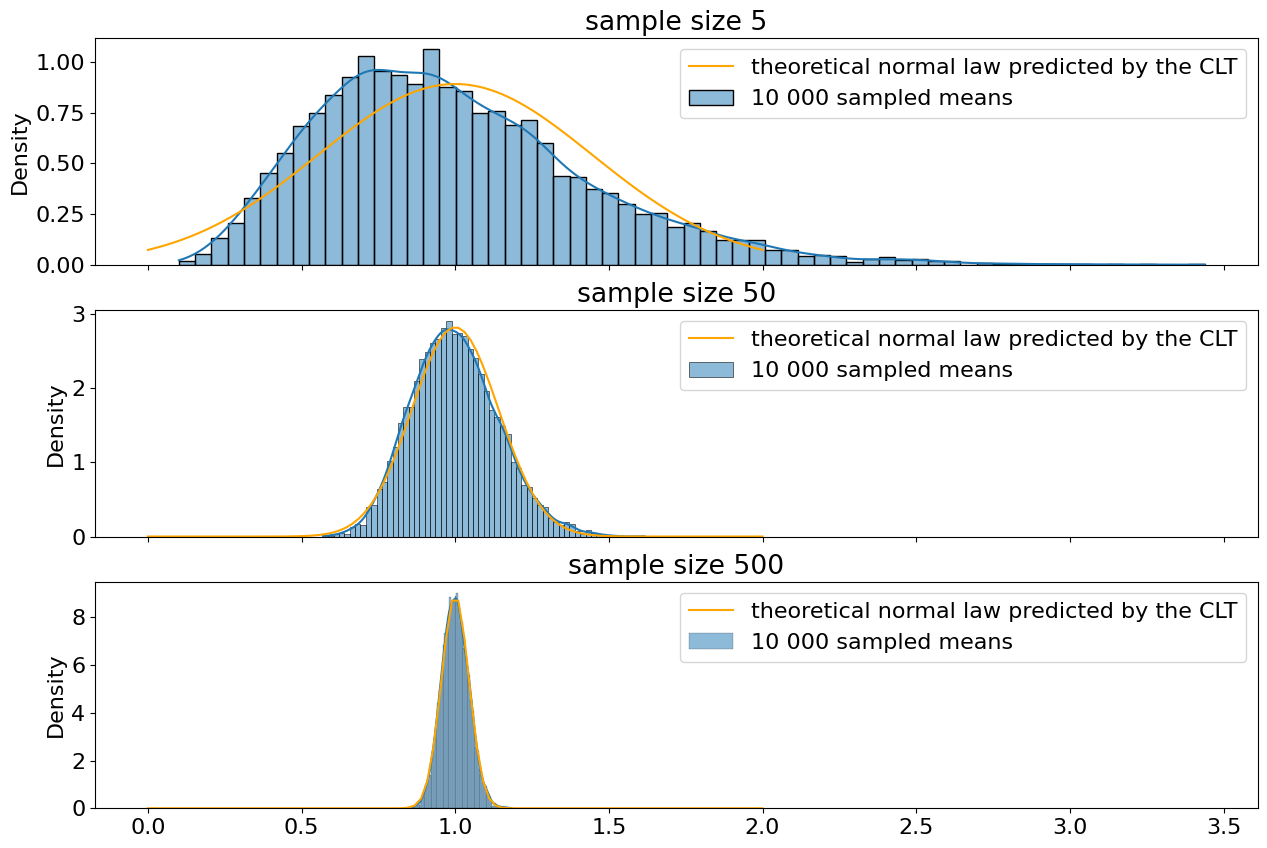

In [8]:
mean_original = 1 # the mean of this exponential law is 1
std_original  = 1 # its standard deviation is 1

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# we take the sample size 5 , 50 and 500 to see the resulting distribution of sample means
for i, sample_size in enumerate([5,50,500]): 

    mean  = mean_original
    stdev = std_original / np.sqrt(sample_size) # expected standard deviation according to Central Limit Theorem

    ax = axes[i]

    sampled_means = [sampling(sample_size).mean() for i in range(10000)] # list containing 10000 sample means

    sns.histplot(sampled_means, kde=True, ax=ax, stat="density", label = '10 000 sampled means') # "stat=density" to make histogram on density (sum area =1) and not counts
    x = np.linspace(0, 2, 100)
    sns.lineplot(x=x, y=stats.norm.pdf(x, loc=mean, scale=stdev), 
                 color='orange', ax=ax, label='theoretical normal law predicted by the CLT')

    ax.set_title(f'sample size {str(sample_size)}')
    ax.legend()
    
plt.show()


The Central Limit Theorem lets us perform inferences even when the underlying distribution is unknown, however it is still an approximation so **when the underlying distribution is known, it is better to use the actual original distribution.**  


[back to the toc](#toc)

<br>

# Exercise 01  <a id='1'></a>

Consider an experiment where we toss a (fair) coin.
We repeat the experiment 10 times (sample size of 10), and compute the mean frequency at which head appear.


The expected mean here would be 0.5 (the probability of getting head for a fair coin).

The standard deviation would be `np.sqrt(0.5 * (1-0.5) ) = 0.5`


1. What would be the normal law followed by the mean of this sample of size 10, according to the CLT ?
2. Do you think the sample is large enough to use a normal law here ?

> Note, this sum of 10 coin tosses is equivalent to a binomial law with n=10 and p=0.5. 

In [8]:
#you can perform experiments using:
def samplingMean(n=10,p=0.5):
    return sum( np.random.random(n)>p ) / n
## returns 1 if all True and 0 if all False

print( 'mean of a sample of size 10:', samplingMean())

mean of a sample of size 10: 0.5


In [1]:
#TODO : Give pseudocode of exercises

In [147]:
m = 0.5
s = 0.5 / np.sqrt( 10 )
print(m,s)

0.5 0.15811388300841897


<Axes: >

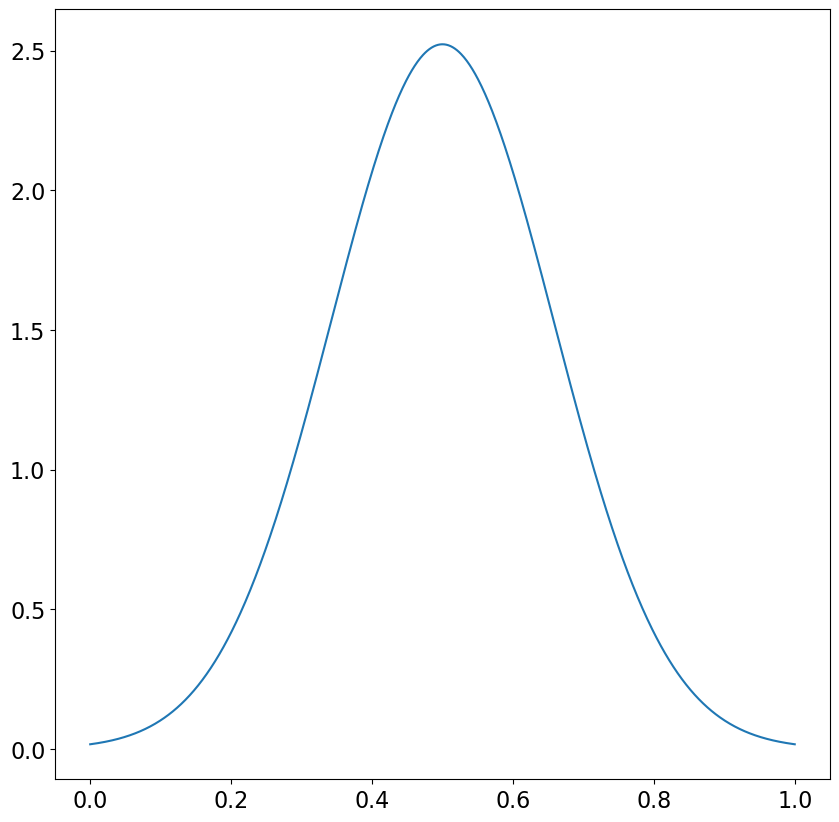

In [148]:
## 1) What would be the normal law followed by the mean of this sample of size 10 according to the CLT ? (plot its pdf)
## According to the CLT
# m=m. s = s/sqrt(n)

x = np.linspace(0,1,1000)
sns.lineplot(x=x, y=stats.norm.pdf(x=x, loc=m,scale=s))

<Axes: ylabel='Count'>

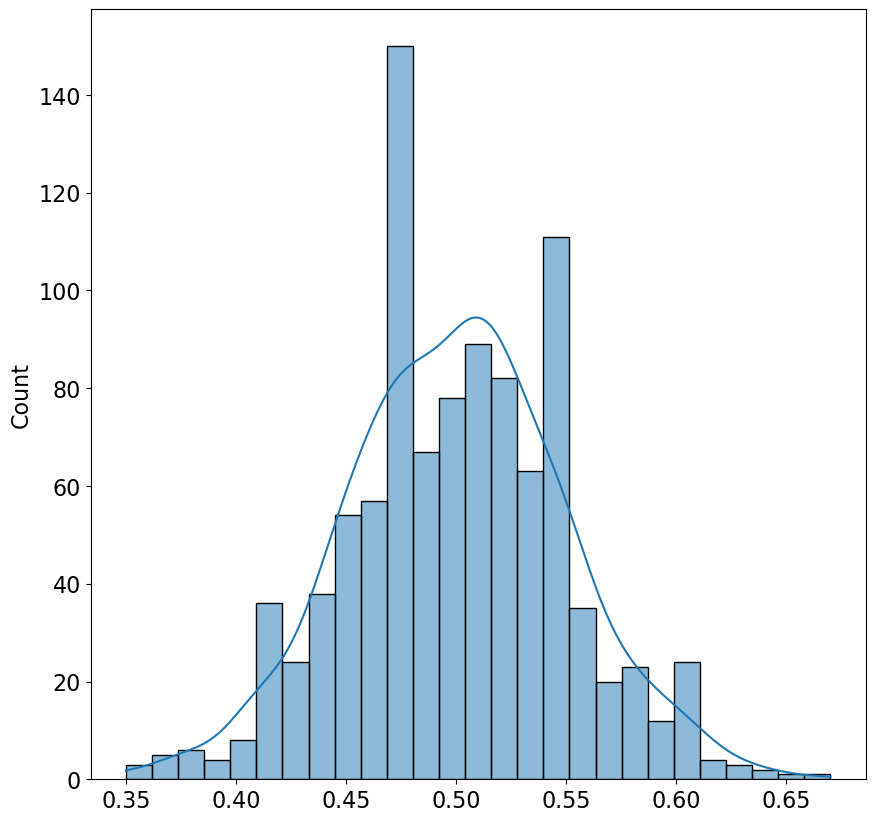

In [149]:
## 2) Do you think the sample is large enough to use a normal law here ? (Print the sampling mean distribution)

## Sample 1 time

## Sample 1000 times 
all_means = []
for i in range(1000):
    all_means.append(samplingMean(n=100,p=0.5))

## Plot distribution
bins = np.linspace(0,1,10)
sns.histplot(all_means, kde=True)

In [151]:
# %load -r 1-5 solutions/solution_02_01.py

# 1. What would be the normal law followed by the mean of this sample of size 10, according to the CLT ?

# a sample of size 10, with a mean of 0.5 and standard deviation of 0.5:
# the mean of this sample follows a normal law of mean 0.5 and standard deviation of 0.5/np.sqrt(10)

<Axes: ylabel='Density'>

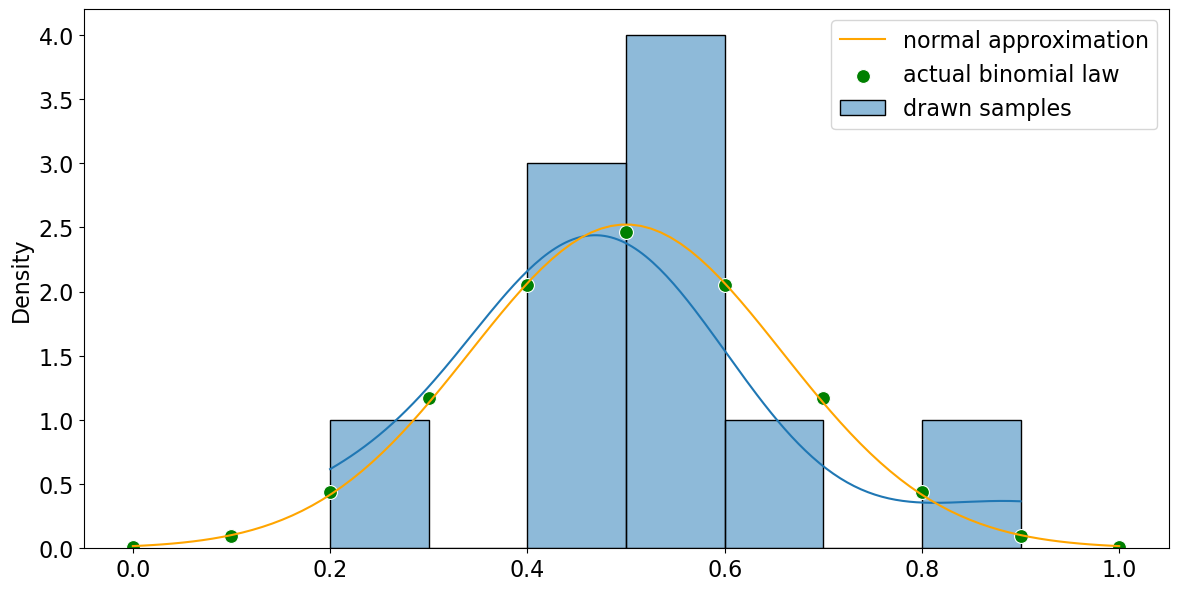

In [152]:
# %load -r 6- solutions/solution_02_01.py

# 2. Do you think the sample is large enough to use a normal law here ?

# let's do some simulations to decide
sampleSize=10
expectedMu = 0.5
expectedStdev = 0.5/np.sqrt(sampleSize)


sampled_means = [samplingMean() for i  in range(10)]
approximation_normal = stats.norm(loc = expectedMu , scale = expectedStdev)
theoretical_binomial = stats.binom(n=10 , p = 0.5)

fig,ax = plt.subplots(figsize=(14,7))

sns.histplot(sampled_means, stat='density' , kde=True, ax=ax , label = 'drawn samples')

x = np.linspace(0,1,100)
sns.lineplot( x=x , y=approximation_normal.pdf(x ) ,
             ax=ax , color="orange" , label = 'normal approximation')
sns.scatterplot( x=np.arange(11)/10 , 
                 y=theoretical_binomial.pmf(np.arange(11))*10 , 
                s=100,  color = 'green' ,ax=ax , label = 'actual binomial law')




---
<br>

So, thanks to the Central Limit Theorem, we know that the sample mean approximately follows a normal distribution, and we can estimate its mean and standard deviation. This allows us to make probabilistic statements about the distance between the sample mean and the real mean. It can let us predict :

* the probability that a given sample mean will fall within a certain distance of the real mean.
* the probability that the real mean will fall within a certain distance of a sample mean.

A common way to express this is through a **confidence interval (CI)**: we fix the probability at 95% and ask "within what distance of the mean does 95% of the density fall?" The boundaries of this interval are found using the **quantiles 0.025** and **0.975**, computed with **.ppf()** (Percent Point Function).


> (definitions) :

> A quantile is a number such that a given percentage of the data lies below it.
e.g. quantile 0.025 has 2.5% of the values below it, quantile 0.5 is the median, quantile 0.975 has 97.5% of the values below it (2.5% above)

> A Confidence Interval (CI) is a range of values centered around the mean that captures a certain percentage of the probability density. For example a 95% Confidence Interval contains 95% of the values. When computing a sample mean, we have a 95% chance that it falls within this interval.
 
---

Let's test this by comparing what the CLT lets us expect and what we observe in practice:


9532 out of 10000 (95.32%) sampled means fall within the 95% Confidence Interval [0.91234775 1.08765225]



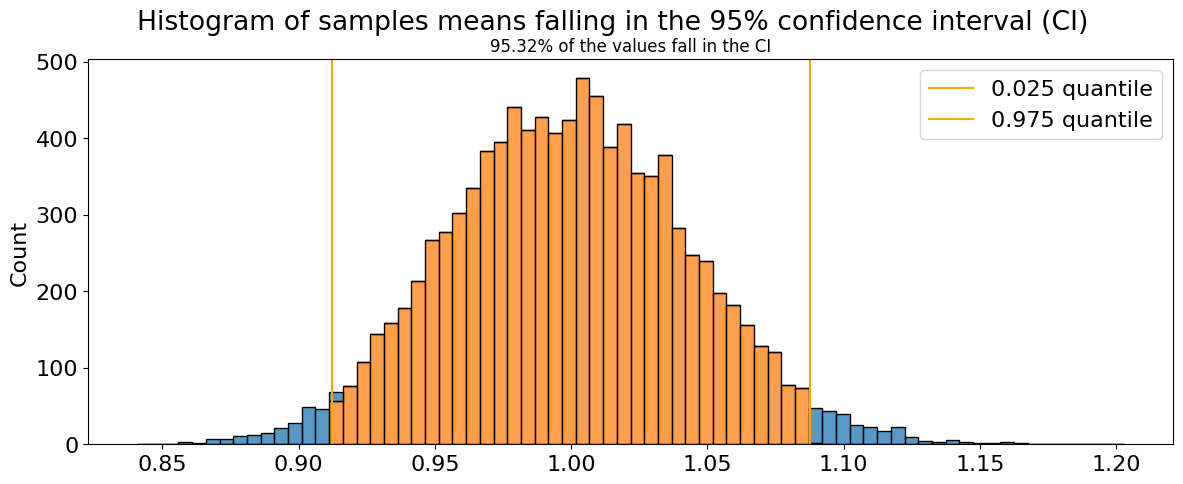

In [9]:
## Let's illustrate the first point : computing the probability that a given sample mean falls within a certain distance of the real mean.
## We do this by computing a 95% Confidence Interval around the real mean.

## Let's work again with the exponential law, and define its parameters :
mean_real = 1 # the mean of this exponential law is 1
std_real  = 1 # its standard deviation is 1

## Now lets configure the samples
sample_size  = 500
mean_CLT  = mean_real                       # expected mean of the distribution of sample means(CLT)
std_CLT   = std_real / np.sqrt(sample_size) # expected standard deviation of the distribution of sample means (CLT)


## Compute the 95% Confidence Interval around the real mean (from the normal law). 
CI = stats.norm.ppf([0.025,0.975], loc=mean_CLT, scale=std_CLT) # Get the 0.025 and 0.975 quantile

## 95% of sampled means should fall within the interval between the two quantiles. Let's test this :

## Get the mean of samples of size "sample_size" 10000 times
n = 10000
sampled_means = np.array([sampling(sample_size).mean() for i in range(n)]) # array of 10000 sample means

## Get the number of values that fall within and outside of the Confidence Interval
nb_in_CI = sum( (sampled_means>CI[0]) * (sampled_means<CI[1]) )
print(f"\n{nb_in_CI} out of {n} ({100*nb_in_CI/n :.2f}%) sampled means fall within the 95% Confidence Interval {CI}\n")

## Visualize the results
fig, ax =plt.subplots(figsize=(14,5))
sns.histplot(x=sampled_means, binwidth=0.005, multiple="stack", ax=ax,
             hue = [(value>CI[0]) and (value<CI[1]) for value in sampled_means]) # This colors values differently if they are in or out of the CI
            
ax.axvline(CI[0] , color='orange', label="0.025 quantile")
ax.axvline(CI[1] , color='orange', label="0.975 quantile")
plt.legend()
plt.suptitle("Histogram of samples means falling in the 95% confidence interval (CI)\n")
plt.title(f"{100*nb_in_CI/n :.2f}% of the values fall in the CI", fontsize=12, )
plt.show()

In [10]:
## Now let's look at the second point: computing the probability that the real mean falls within a certain distance of a sample mean.
## This can also be represented by computing a 95% Confidence Interval around the sample mean.

nb_in_CI = 0

for i in range(n):
    
    ## get one sample and compute its average, the theoretical mean is 1.
    sampled_mean = sampling(sample_size).mean()
    
    ## Compute the 95% Confidence Interval around the sample mean  
    CI = stats.norm.ppf([0.025,0.975], loc=sampled_mean, scale=std_CLT) # this time we center the CI around the sample mean, not the real mean
    
    ## Checking if the 95% confidence interval indeed contains the real mean
    if mean_real>CI[0] and mean_real<CI[1]:
        nb_in_CI += 1

print(f"\n{nb_in_CI} out of {n} ({100*nb_in_CI/n :.2f}%) times, the real mean falls within the 95% confidence interval centered around the sample mean.")


9528 out of 10000 (95.28%) times, the real mean falls within the 95% confidence interval centered around the sample mean.


So, here, we were able to generate a confidence interval around the sample mean such that 95% of the time, such an interval contains the real mean.

**Overview of functions to manipulate the theoretical distributions :**

| Function | Description |
|---|---|
| `.pdf` / `.pmf` | Takes values and returns the density / probability of drawing these particular values |
| `.cdf` | Takes values and returns the probability of drawing these values or less |
| `.ppf` | Takes a quantile and returns the corresponding value (inverse of the CDF) |



[back to the toc](#toc)

<br>

# Exercise 02  <a id='2'></a>


Say you toss 10 coins, and obtain heads 7 times.

This experiment is equivalent to a binomial law with n=10 and p=0.5. `stats.binom(n=10,p=0.5)`
Using `.pmf()` , `.cdf()`, and/or `.ppf()`, answer the following questions :

1. How likely was this result, provided the coin is fair? 
2. How likely was it to come up with at most 7 heads , provided the coin is fair? 
3. How likely was it to come up with at least 7 heads , provided the coin is fair? 
4. How likely was it to come up with a result at least as different from the expected mean of 5, provided the coin is fair? 
5. How about if you come up with 1 heads out of 10 ? Do you think the coin is fair in that case? 



1. How likely was this result, provided the coin is fair? 

In [ ]:
# %load -r 1-12 solutions/solution_02_02.py
# 1. How likely was this result, provided the coin is fair? 

2. How likely was it to come up with at most 7 heads , provided the coin is fair? 

In [ ]:
# %load -r 13-21 solutions/solution_02_02.py
# 2. How likely was it to come up with at most 7 heads , provided the coin is fair? 

3. How likely was it to come up with at least 7 heads , provided the coin is fair? 

In [ ]:
# %load -r 22-26 solutions/solution_02_02.py
# 3. How likely was it to come up with at least 7 heads , provided the coin is fair? 

4. How likely was it to come up with a result at least as different from the expected mean of 5, provided the coin is fair? 

In [ ]:
# %load -r 27-32 solutions/solution_02_02.py
# 4. How likely was it to come up with a result at least as different from the expected mean of 5, provided the coin is fair? 

5. How about if you come up with 1 heads out of 10 ? Do you think the coin is fair in that case? 

In [ ]:
# %load -r 33- solutions/solution_02_02.py
# 5. How about if you come up with 1 heads out of 10 ? Do you think the coin is fair in that case? 


[back to the toc](#toc)

<br>

# 2. Statistical hypothesis testing  <a id='3'></a>

We now know what the laws are and how they behave. Now we will learn how to use these probability laws to test our hypotheses.

Recipe for a statistical hypothesis test :

1. Define a **null hypothesis** $\boldsymbol{H_0}$ and an **alternative hypothesis** $\boldsymbol{H_1}$. These hypotheses are statements about the “real world”.
2. Define a **test statistic** (e.g. the mean of a sample, a difference of mean,... ) and its expected behaviour under the null hypothesis.
3. Collect data and calculate the **observed value of the test statistic**.
4. Compare the observed test statistic to its expected values under the null hypothesis

**H<sub>0</sub>**
A **test statistic** is a numerical summary derived from a sample, which must be calculable (exactly or approximately) from its sampling distribution under the null hypothesis.

### Example 

Say we want to compare the sizes of two populations of plants:
- The first population is unfertilized, with a known average size $m_0 = 1$.
- The second population is fertilized, with an unknown mean $m$ but a known standard deviation $s = 2$
>(Note that knowing the population standard deviation in advance is mainly theoretical, in practice it is rarely the case).

We want to know whether fertilization has any effect on plant size, which is equivalent to asking whether $m$ differs from $m_0$.  
Now we reproduce every step described above :

1) Define $H_0$ and $H_1$
   * Null hypothesis $H_0 : m = m_0$ (the two means are the same, meaning the fertilizer has no effect on average plant size.
   * Alternative hypothesis $H_1 : m \neq m_0$ (the two means differ, meaning the fertilizer has an effect, positive or negative)
   * According to the CLT the mean of a sample of $n$ measures should follow a normal distribution : $\bar{x} \sim N (m , s / \sqrt{n} )$.
   * **Under the null hypothesis** : $\bar{x} \sim N(m_0 , s / \sqrt{n} )$

In practice, it is more practical to **center and scale** this distribution:
$$\bar{x} \sim N(m_0 , s / \sqrt{n} ) \quad \rightarrow \quad \frac{\bar{x} - m_0}{s / \sqrt{n}} \sim N( 0 , 1 )$$

2. The **test statistic** :
$$\frac{\bar{x} - m_0}{s / \sqrt{n}}$$

3. Say we collected $n=100$ measures of the fertilized population and their mean is $\bar{x}=1.42$.

&emsp; Thus the test statistic is $\frac{\bar{x} - m_0}{s / \sqrt{n}} = \frac{1.42 - 1}{2 / \sqrt{100}} = 2.1$

4. What is the probability of obtaining a test statistic at least as extreme as 2.1 under the null hypothesis ?

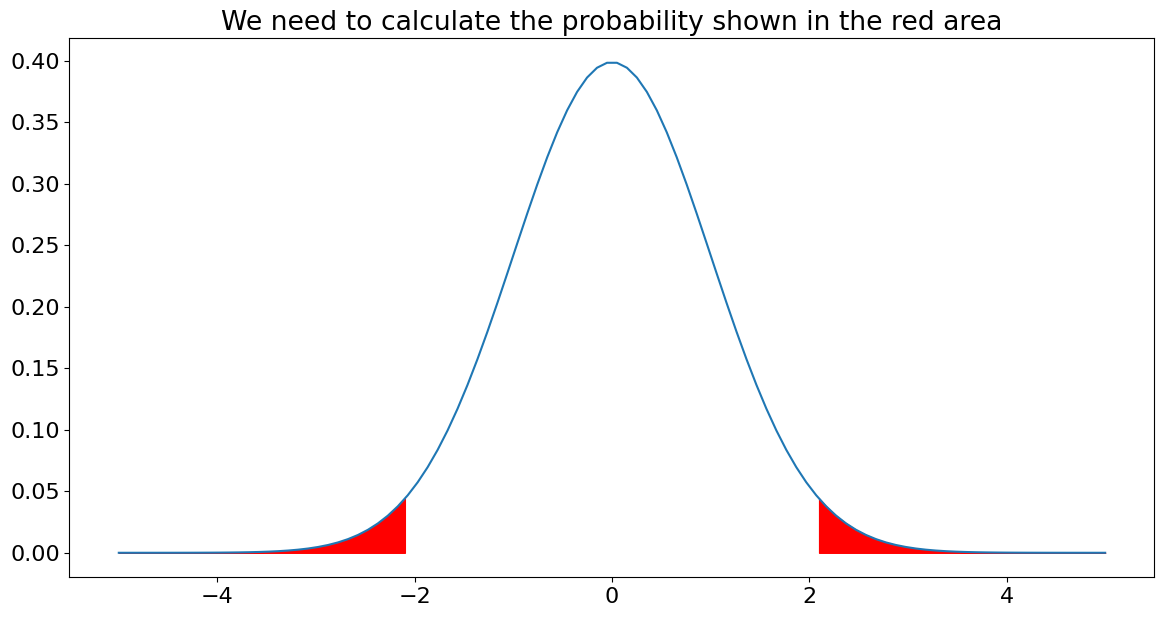

In [11]:
## Visualize the normal law N(0,1) and the values at least as extreme as 2.1

## Plot normal law pdf
x = np.linspace(-5, 5, 100)
fig, ax = plt.subplots(figsize=(14,7))
sns.lineplot(x=x , y=stats.norm.pdf(x))  # By default, it is a N(0.1) (mean=0, scale-1)

## Color values at least as extreme as our observed value in red
x1 = np.linspace(-5, -2.1, 100)
plt.fill_between(x1, stats.norm.pdf(x1), color='red')
x2 = np.linspace(2.1, 5, 100)
plt.fill_between(x2, stats.norm.pdf(x2), color='red')

plt.title("We need to calculate the probability shown in the red area")
plt.show()

In [12]:
## To do this it is very easy, we need to add the probability of falling in the left tail (below -2.1) and the probability of falling in the right tail (above 2.1)
test_statistic = 2.1

proba_left_tail    = stats.norm.cdf(-abs(test_statistic))     # probability of observing <= -2.1
proba_right_tail   = 1 - stats.norm.cdf(abs(test_statistic))  # probability of observing >=  2.1
proba_more_extreme = proba_left_tail + proba_right_tail       # probability of observing <= -2.1 or >=  2.1 

print(f"The probability of observing a value at least as extreme as 2.1 under the null hypothesis is {proba_more_extreme}.")

The probability of observing a value at least as extreme as 2.1 under the null hypothesis is 0.035728841125633105.


This is the definition of the **p-value** : the probability of obtaining a test statistic at least as extreme as the observed one under the null hypothesis.

### two-sided or one-sided test?

Above, you can see that when we get the p-value, we account for test statistics at least as extreme in both directions (in the negative and in the positive).

This is what we call a **two-sided** hypothesis test, where $H_1 : m \neq m_0$ includes the possibility that $m>m_0$ as well as $m<m_0$.

It is possible to perform a **one-sided** hypothesis test, where for example, $H_1 : m > m_0$, in which case the p-value would account for the probability of observing a value as extreme in the direction of $H_1$.

In our previous example, a one-sided test would give the alternative hypothesis $H_1 : m > m_0$ "The fertilizer has a positive effect on average plant size"

The one-sided p-value is 0.017864420562816563



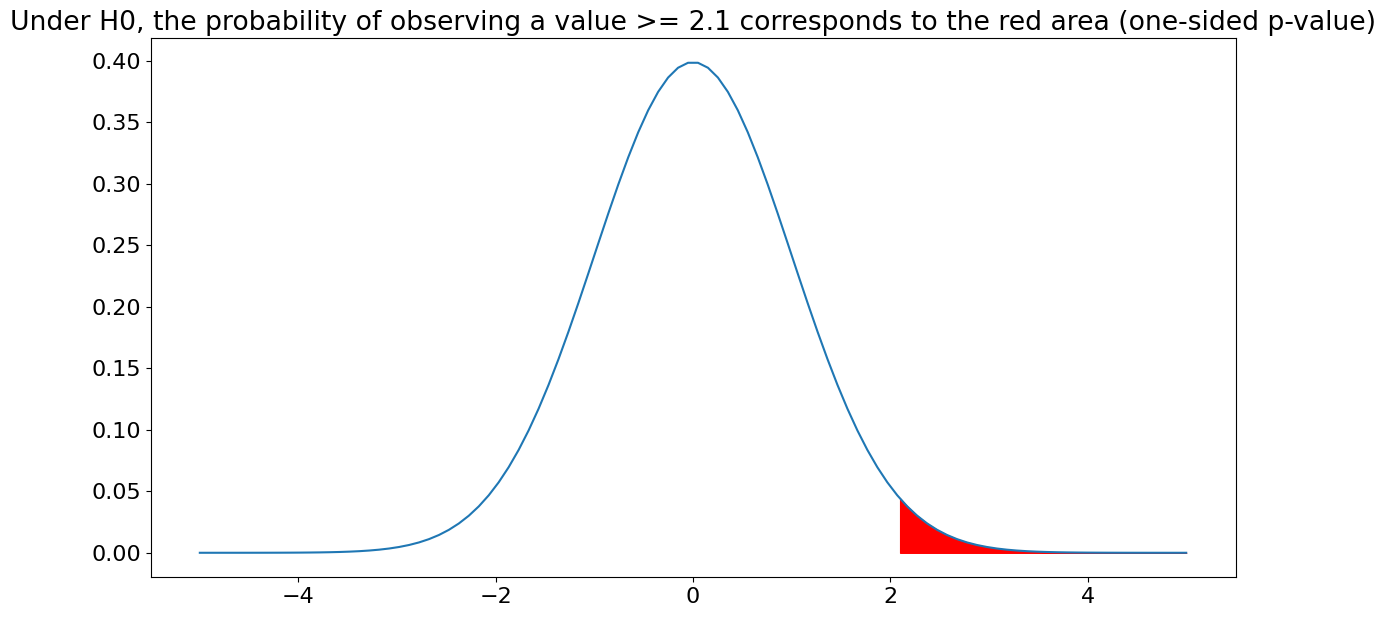

In [13]:
## Same as above but for a one-sided hypothesis H1 : m > m0

## Compute p-value
test_statistic = 2.1
proba_right_tail = 1 - stats.norm.cdf(abs(test_statistic)) 
proba_more_extreme = proba_right_tail  # We only consider the probability of observing >= 2.1
print(f"The one-sided p-value is {proba_more_extreme}\n")


## Visualize what we are computing
x = np.linspace(-5, 5, 100)
fig, ax = plt.subplots(figsize=(14,7))
sns.lineplot(x=x, y=stats.norm.pdf(x))
x2 = np.linspace(test_statistic, 5, 100)
plt.fill_between(x2, stats.norm.pdf(x2), color='red')
plt.title("Under H0, the probability of observing a value >= 2.1 corresponds to the red area (one-sided p-value)")
plt.show()


> (Note that the distribution of the test statistic is symmetric, so the 2-sided p-value is twice that of the 1-sided p-value)


[back to the toc](#toc)

<br>

## 2.1 t-test : difference between two means  <a id='4'></a>

The example test we have just shown requires the population standard deviation to be known in advance, which is, in practice, often not the case.

When the population standard deviation is unknown, we can **estimate the standard deviation using the sample**, but then the test statistic does not follow a normal distribution but rather a **t-distribution with $\boldsymbol{n-1}$ degrees of freedom**, where $n$ is the sample size.
>Degrees of freedom are a statistical concept that can be difficult to understand at first. You can consider that they roughly reflect the amount of information available. Their full definition is : number of independent values (pieces of information), which were included into calculation of an estimate.
  
>Note that the larger the sample, the higher the degrees of freedom, and the more the t-distribution resembles a normal distribution. This is because with more data, the sample standard deviation becomes a more reliable estimate of the true population standard deviation.

[]

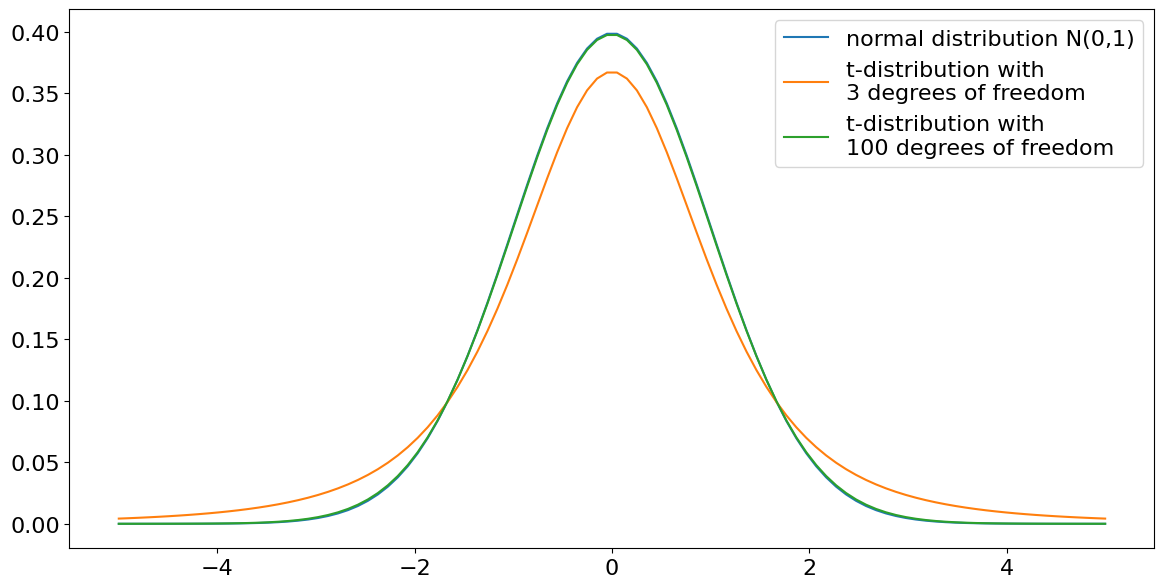

In [14]:
## Plot normal distribution and t-distributions for different degrees of freedom
## You can see that the higher the degrees of freedom, the more it resembles normal law.
x = np.linspace(-5, 5, 100)
fig, ax = plt.subplots(figsize=(14,7))
sns.lineplot(x=x, y=stats.norm.pdf(x)     , label='normal distribution N(0,1)')
sns.lineplot(x=x, y=stats.t.pdf(x,df=3)   , label='t-distribution with\n3 degrees of freedom')
sns.lineplot(x=x, y=stats.t.pdf(x,df=100) , label='t-distribution with\n100 degrees of freedom')
plt.plot()
## NB: Here the normal distribution has the same shape than t-distribution with 100+ degrees of freedom

This t-distribution can be used to test the (in)equality of the mean of two unpaired samples.

Consider two populations, of respective true population means $\mu_1$ and $\mu_2$, from which we sample $n_1$ and $n_2$ individuals and observe the sample means $\bar{x}_1$ and $\bar{x}_2$ and standard deviations $s_1$ and $s_2$.

The null hypothesis for this t-test is $H_0 : \mu_1 = \mu_2$, while the alternative hypothesis is $H_1 : \mu_1 \neq \mu_2$.

There are a number of assumptions around that test:
 * the mean of each sample are normally distributed. When the sample size is large enough, the CLT ensures this
 * the data used to carry out the test should be sampled independently from the two populations being compared

The **t-test of independence**, also called **Welch's t-test**, is defined as follows :

- the test statistic is : 
$$\frac{\bar{x}_1-\bar{x}_2}{\sqrt{(s_1^2/n_1+s_2^2/n_2)}}$$

- with the variances calculated as :
$$\large s_1^2 = \frac{\sum_{i=1}^{n_1}(x_i-\bar{x}_1)^2}{n_1-1}$$
$$\large s_2^2 = \frac{\sum_{j=1}^{n_2}(x_j-\bar{x}_2)^2}{n_2-1}$$

And the test statistic under the null hypothesis follows a t-distribution with degrees of freedom equal to :

$$df = \Large \frac{[\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}]^2}{\frac{(\frac{s_1^2}{n_1})^2}{n_1-1} + \frac{(\frac{s_2^2}{n_2})^2}{n_2-1}}$$

> note : if the two samples variance are equal there is another way of computing the degree of freedom that gives a bit more statistical power. But this requires that you test for variance equality first.


Let's try this with an example:

First lines of the dataset :

   diet genotype  weight
0  HFD       WT    31.2
1  HFD       WT    32.1
2  HFD       WT    30.3
3  HFD       WT    45.0
4  HFD       WT    39.2 



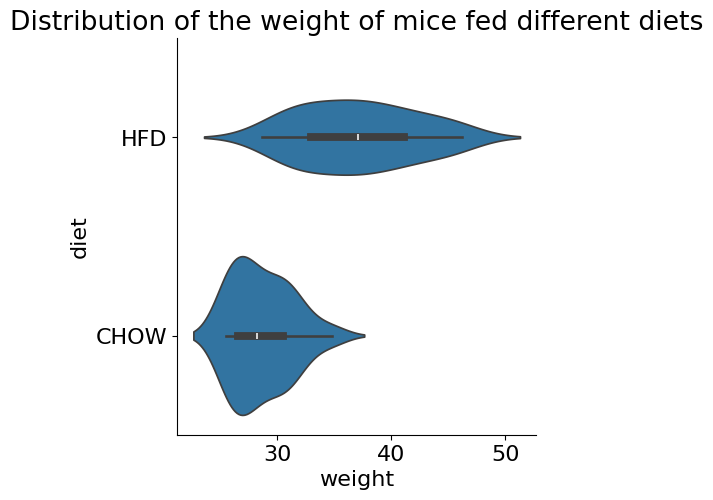

In [15]:
## Import a dataset containing data about the weight of mice of different genotypes and subjected to different diets
mice_data = pd.read_csv( 'data/mice_data.csv' ) 
print("First lines of the dataset :\n\n", mice_data.head(), "\n")

## Plot the weight distribution for the different diets
## NB: CHOW diet reffers to a "standard" laboratory diet
##     HFD refers to "High Fat Diet"
sns.catplot(x='weight' , y='diet' , data=mice_data , kind='violin')
plt.title("Distribution of the weight of mice fed different diets")
plt.show()

In [16]:
## Manual computation of Welch's t-test

## Get the weights for each diet
data_CHOW = mice_data['weight'][mice_data['diet'] == 'CHOW']  # A "list-like" containing all weights of mice fed CHOW diet
data_HFD  = mice_data['weight'][mice_data['diet'] == 'HFD' ]  # A "list-like" containing all weights of mice fed HFD  diet

## Sample sizes
n1 = len(data_CHOW)
n2 = len(data_HFD)

## Means
mean_CHOW = np.mean(data_CHOW)
mean_HFD  = np.mean(data_HFD )

## Variances
variance_CHOW = np.var(data_CHOW , ddof=1) # ddof, for delta degree-of-freedom, uses n-1 as the denominator
variance_HFD  = np.var(data_HFD  , ddof=1)

## Compute the t-statistic 
t_stat = (mean_CHOW - mean_HFD) / (np.sqrt((variance_CHOW/n1) + (variance_HFD/n2)))
print(f"Test statistic \t\t: {t_stat}")

## Get the degrees of freedom
deg_freedom = (((variance_CHOW/n1) + (variance_HFD/n2))**2) / ((((variance_CHOW/n1)**2)/(n1-1)) + (((variance_HFD/n2)**2)/(n2-1)))
print(f"Degrees of freedom \t: {deg_freedom}")

## Get the p-value, we do this two-sided as we did earlier 
proba_left_tail   =     stats.t.cdf(-abs(t_stat), df=deg_freedom)  # Probability of observing a value smaller than -|t_stat|
proba_right_tail  = 1 - stats.t.cdf( abs(t_stat), df=deg_freedom)  # Probability of observing a value higher  than  |t_stat|
pval              = proba_left_tail + proba_right_tail
print(f"p-value \t\t: {pval}")


Test statistic 		: -7.738758252909616
Degrees of freedom 	: 44.254639192414686
p-value 		: 9.244178357624686e-10


Woof, it works, but it is a bit tedious to code.

Of course, there exists a function in the `stats` module:

In [17]:
t_stat, pval = stats.ttest_ind(data_CHOW, data_HFD, equal_var=False) #use equal_var=True if you have tested for variance equality
print(f"Test statistic \t\t: {t_stat}")
print(f"p-value \t\t: {pval}")


Test statistic 		: -7.738758252909616
p-value 		: 9.244177959442145e-10


We get the same results.

**micro-exercise** TODO
1. Given these results, what is our conclusion there ?
2. if the p-value was 0.3, what would be our conclusion ?

<details style="border: 2px solid #B8C3EA; margin: 1em 0.2em;padding: 0.5em; cursor: pointer;"><summary>👁 View solution </summary>
    
1. Here, the p-value is very small (>$10^{-9}$), which leads us to reject $H_0$.
2. A p-value of 0.3 would be interpreted as the idea that the observed data is not very unlikely under the null hypothesis. Following the commonly used p-value threshold of 0.05, we would say that we fail to reject $H_0$ here.

> NB: we say we "fail to reject $H_0$" rather than "accept $H_0$" because p-values are not meant to inform us on the probability of $H_0$. We will spend more time on that lower in this notebook when we discuss error type and statistical power.


</details>


[back to the toc](#toc)

<br>

## 2.2 t-test assumptions and what to do when they are not respected  <a id='5'></a>

As you have seen, a p-value is valid with respect to a particular null-hypothesis that relies on a number of assumptions regarding the data behavior.

If these **assumptions are false, then the p-value loses its meaning.**

Let's get back to the assumptions of Welch's t-test:
 1. the data used to carry out the test should be sampled independently from the two populations being compared
 
 2. the mean of each sample is normally distributed. When the sample size is large enough, the CLT ensures this

Point `1.` should be taken care of when designing the experiment and collecting the data. 
>Note that there also exist a version of the t-test for the case where all points are paired (e.g. when you have data for the effect of 2 drugs for each patients). 

For point `2.`, ideally the samples themselves should follow a normal distribution (this is the original requirement of Student's t-test). Otherwise you should make sure the sample size is large enough for the sample mean to follow something resembling a normal law.

>Note that there is no set sample size above which the CLT approximation is guaranteed to be reliable : it is dependent on the specific properties of the distribution(s) you sample from.

<br>

Let's demonstrate how things can go wrong. We take two samples from the **same distribution** and perform a t-test on them. If the assumptions hold, we should observe a p-value < 0.05 in approximately 5% of cases — no more, no less.

normal law	proportion of sampled p-values under 0.05 :	0.0506
pareto law	proportion of sampled p-values under 0.05 :	0.0202



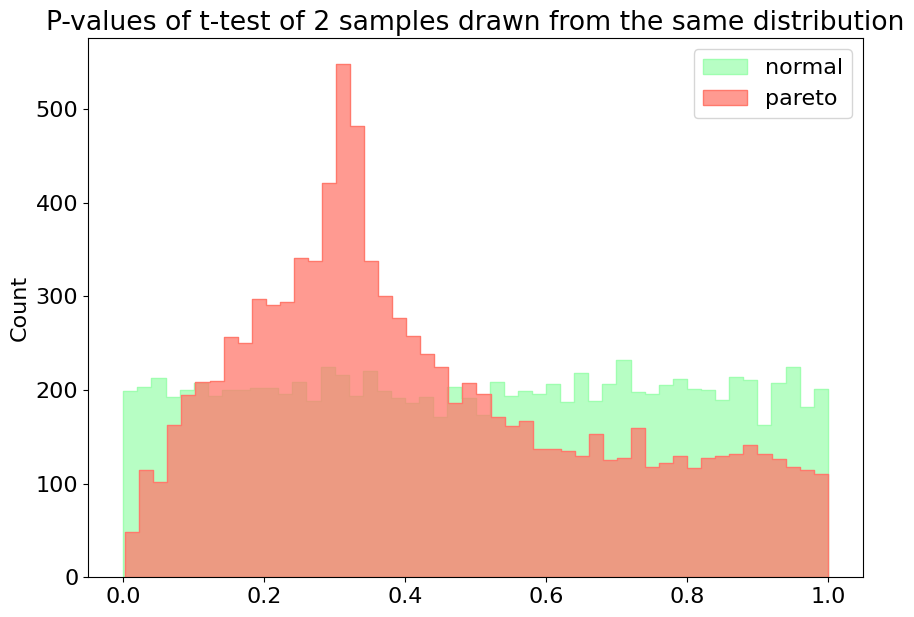

In [19]:
## experimental setups : We will compare two samples from the same distribution and compute the p-value
## We will repeat this 10 000 times for two different distributions : Normal distribution and pareto distribution
## Then we will observe the proportions of p-values that fell below 0.05 (Since the two samples come from the same law, we expect this proportion to be 5%)

## Sample size
n1 = n2 = 50

##-------------------------------------------------
##-- First experimental setup : Normal distribution

## Parameters of normal law
mean, std = 5, 3

## Evaluate p-value distribution 
nb_under_05 = 0   # nb of time pval was below 0.05
PV_norm     = []  # list of all p-values obtained from the normal law experimental setup ???

## Sample and compute p-value 10 000 times
for i in range(10000):

    ## Sample from normal law
    sample1 = np.random.normal(loc=mean, scale=std, size=n1)
    sample2 = np.random.normal(loc=mean, scale=std, size=n2)

    ## Compute t-test
    t_stat, pval = stats.ttest_ind(sample1, sample2, equal_var=True)

    ## Store p-value
    PV_norm.append(pval)
    if pval < 0.05:
        nb_under_05 += 1

print(f"normal law\tproportion of sampled p-values under 0.05 :\t{nb_under_05/10000}")

##-----------------------------------------------------------------------------------------------
##-- Second setup : rather than sampling in a normal law, we will sample in a pareto distribution
# https://en.wikipedia.org/wiki/Pareto_distribution

## Same process as above
nb_under_05 = 0
PV_pareto = []

## Sample and compute p-value 10 000 times
for i in range(10000):

    ## Sample from pareto law
    sample1 = np.random.pareto(a=1, size=n1) 
    sample2 = np.random.pareto(a=1, size=n2) 

    ## Compute t-test
    t_stat, pval = stats.ttest_ind(sample1, sample2, equal_var=True)

    ## Store p-value
    PV_pareto.append(pval)
    if pval < 0.05:
        nb_under_05 += 1
        
print(f"pareto law\tproportion of sampled p-values under 0.05 :\t{nb_under_05/10000}\n")

##----------------
##-- Plot p-values

fig, ax = plt.subplots(1, 1, figsize=(10,7))
sns.histplot(PV_norm  , label="normal", binwidth=0.02, element="step", color='xkcd:mint'  , ax=ax)
sns.histplot(PV_pareto, label="pareto", binwidth=0.02, element="step", color='xkcd:salmon', ax=ax)
ax.legend()
ax.set_title("P-values of t-test of 2 samples drawn from the same distribution")
plt.show()


As you can see here, the p-values from the normal distribution (green) are approximately uniformly distributed between 0 and 1. Roughly 5% fall below 0.05, as expected. For the pareto distribution (pink) however, the p-values are far from being uniformly distributed. Way fewer than 5% of the p-values fall below 0.05, therefore the p-value loses its meaning here.

This illustrates the fact that the p-value is only valid as long as the assumptions of the test hold. When they are violated, the test becomes unreliable and we can no longer trust the p-value. (like in the case here, where the sample means do not follow a normal distribution closely enough).

> Note that simulating the behavior of data under the null hypothesis is an excellent way to explore how these tests work.

The simplest way to check that the normality assumption is to check the normality of the data itself. Indeed, if the data follows a normal distribution, then the sample means are guaranteed to follow one too.

[back to the toc](#toc)

<br>

### 2.2.1 testing normality  <a id='6'></a>

There exist several methods to test for normality and we recommend to combine a **graphical method** 
with a **classic statistical test** to get a better picture of the data.

You can get **a graphical overview** of how well your data fits a normal distribution using a Quantile-Quantile-plot (**Q-Q plot**). 
The idea here is to compute several quantiles of your sample and plot them against the expected quantiles of the normal law.
**Samples drawn from a normal law will form a diagonal line.**


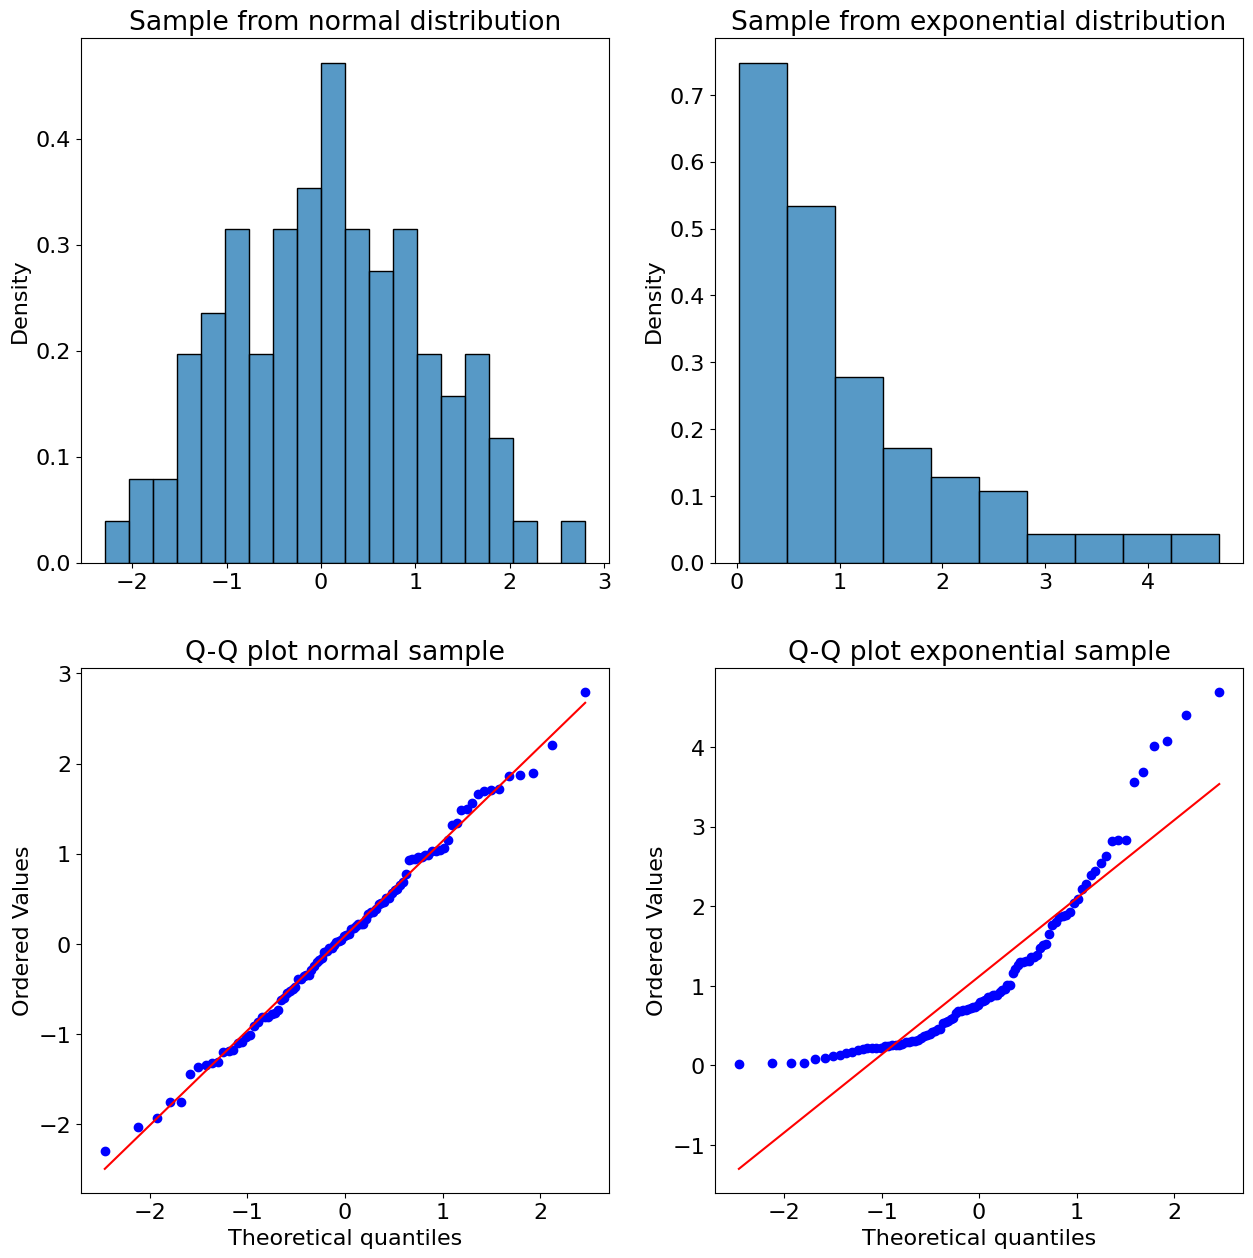

In [20]:
## Sample values from a normal law and exponential law
sample_norm = np.random.normal(size = 100)      # sample from a normal law
sample_exp  = np.random.exponential(size = 100) # sample from another distribution (not normal)

##-- Plot the QQplot for the two samples

fig,axes = plt.subplots(2,2 , figsize = (15,15) )

## Plot sample distribution for visualization purposes
sns.histplot(sample_norm, ax=axes[0,0], stat="density", bins=20)
axes[0,0].set_title("Sample from normal distribution")

sns.histplot(sample_exp, ax=axes[0,1], stat="density", bins=10)
axes[0,1].set_title("Sample from exponential distribution")

## QQplots   
## NB: stats.probplot plots against the normal law by default, meaning it tests for normality
stats.probplot(sample_norm, plot=axes[1,0] ) # on the left: points align along the diagonal
axes[1,0].set_title("Q-Q plot normal sample")

stats.probplot(sample_exp, plot=axes[1,1] ) # on the right: points deviate from the diagonal
axes[1,1].set_title("Q-Q plot exponential sample")

plt.show()


Regarding the **statistical test**, we propose the **Shapiro-Wilk** test. 
It has been shown to have a slighly better power than other tests by a [2011 study](https://web.archive.org/web/20150630110326/http://instatmy.org.my/downloads/e-jurnal%202/3.pdf).

This test relies on the comparison between each sorted point in the observed distribution and its expected value in a normal distribution. 
Originally proposed for no more than 50 observations, refinements to the algorithm now make this test reliable up to 5000 points (as mentioned in `help(scipy.stats.shapiro)`) ; above this number another test, such as D'Agostino's  (`scipy.stats.normaltest`), should be used instead.

This test's null hypothesis is normality — a small p-value indicates a rejection of normality, meaning the data is unlikely to be normally distributed."

In [21]:
## Compute Shapiro-Wilk's test p-value
t_stat, pval = stats.shapiro(sample_norm)
print(f"normal data\t\tShapiro-Wilk's normality test p-value\t{pval}\t(large p-value expected : data is normal)")
t_stat, pval = stats.shapiro(sample_exp)
print(f"exponential data\tShapiro-Wilk's normality test p-value\t{pval}\t(small p-value expected : data is not normal)")

normal data		Shapiro-Wilk's normality test p-value	0.9481390986163682	(large p-value expected : data is normal)
exponential data	Shapiro-Wilk's normality test p-value	5.525952861144951e-09	(small p-value expected : data is not normal)


**micro-exercise**

Check the normality for the weights of mices subjected to the CHOW and HFD diets.

In [ ]:
## TODO
CHOWdata = mice_data['weight'][ mice_data['diet'] == 'CHOW' ]
HFDdata = mice_data['weight'][ mice_data['diet'] == 'HFD' ]

In [ ]:
len( HFDdata ) , len(CHOWdata)

<details style="border: 2px solid #B8C3EA; margin: 1em 0.2em;padding: 0.5em; cursor: pointer;"><summary>👁 View solution - QQplot </summary>

```python
fig,axes = plt.subplots(1,2 , figsize = (15,7) )
_ = stats.probplot( CHOWdata , plot=axes[0] )
_ = stats.probplot( HFDdata , plot=axes[1] )
```

</details>

<details style="border: 2px solid #B8C3EA; margin: 1em 0.2em;padding: 0.5em; cursor: pointer;"><summary>👁 View solution - statistical test </summary>

```python
tstat,pval = stats.shapiro(CHOWdata)
print('CHOW data     ',"Shapiro-Wilk's normality test p-value",pval , sep='\t')
tstat,pval = stats.shapiro(HFDdata)
print('HFD data',"Shapiro-Wilk's normality test p-value",pval, sep='\t')
```
output:
```
CHOW data     	Shapiro-Wilk's normality test p-value	0.15705916285514832
HFD data	Shapiro-Wilk's normality test p-value	0.3795003890991211
```

Our conclusion is that we do not reject the hypothesis of normality for neither the CHOW or the HFD data. 
Consequently, we can move forward with our t-test.


</details>

When the data itself is not normal, a good understanding of the measure you are taking and a large enough sample size may allow you to assume that the mean of the samples is normally distributed.

However, in the general case, it is then better to avoid using the t-test and prefer a different type of test that does not make the assumption about the normality of the mean : **nonparametric tests**.


[back to the toc](#toc)

<br>

# TODO stopped here
### 2.2.2 nonparametric testing : Mann–Whitney U test (also called Wilcoxon rank-sum test) <a id='7'></a>

**Nonparametric statistics** is the branch of statistic that does not rely on the known families of distributions (normal, binomial, exponential, ...) that requires specified parameters (mean and variance, $n$ and $p$ , $\lambda$ , ... ). 
Thus, nonparametric statistics is particularly useful when assumptions of normality do not hold.

The **Mann–Whitney U test** is a nonparametric test 
to determine if two samples have different locations


**Assumptions**
 * All observations from samples are independent of each other
 * The values in each samples are ordinal (i.e.,thay can be compared)

**H0** : the probability that a randomly selected value from the first sample is lower than a randomly selected value from the second sample is equal to the probability of being greater.

**Test statistic** : $U$, which is computed by looking at each observation $i_1$ in the first sample and counting $1$ for each observation lower than $i_1$ in the second sample (count 0.5 for ties).

![Mann-Whitney U illustration](images/MWU.png)


**Example**

Say you have two samples:
* sample1 : 1.2 , 1.5 , 2.2 , 3.0 , 3.1 
* sample2 : 1.1 , 1.8 , 2.2 , 2.4 , 2.8 

for each observation in sample1, let's count the number of values lower to it in sample2 :


In [ ]:
sample1= [ 1.2 , 1.5 , 2.3 , 3.0 , 3.1 ]
sample2= [ 1.1 , 1.8 , 2.2 , 2.4 , 2.8 ]
def computeU(sampleA , sampleB):
    U1=0
    U2=0
    for i in sampleA:
        for j in sampleB:
            if j<i:
                U1 += 1
            elif i==j:
                U1 += 0.5
                U2 += 0.5
            else:
                U2 += 1
    return min(U1,U2)
U_manual = computeU(sample1 , sample2)

U1_scipy , pval = stats.mannwhitneyu(sample1,sample2,method = 'exact' , alternative='two-sided') 
U2_scipy , pval = stats.mannwhitneyu(sample2,sample1,method = 'exact' , alternative='two-sided') 
U_scipy = min(U1_scipy , U2_scipy) 
# scipy implements a computation of U that only accounts for cases where sample1 is above sample2 ...

print('U manual :',U_manual)
print('U scipy  :',U_scipy)

In [ ]:
pval

In [ ]:
import scipy
scipy.__version__


**important note :** for versions of scipy < 1.7 , the p-value of `scipy.stats.mannwhitneyu` is only valid when the number of observations in both samples is above 20 (see [their doc](https://docs.scipy.org/doc/scipy-1.6.0/reference/generated/scipy.stats.mannwhitneyu.html)). If the number of observations is < 20, you have to rely on old-fashioned tables such as [this one from uMBoston](http://ocw.umb.edu/psychology/psych-270/other-materials/RelativeResourceManager.pdf).
> To use this table, look up the number in the cell corresponding to the size of both samples and the desired confidence level. If U is under this number then the test is significant and H0 is rejected.
Here, $n1=n2=5$, for a confidence level of $0.05$ then the test is significant only when $U<2$.


Note that **the null hypothesis of the Mann-Whitney U test is different from the one of the t-test**.
The t-test looks for equality of the means, while the U tests for equiprobabilities of seing lower/higher values.

This means that they will sometimes behave quite differently (See for instance [Fagerland2012](https://bmcmedresmethodol.biomedcentral.com/articles/10.1186/1471-2288-12-78), which shows that Mann-Whitney U rejects $H_0$ with a high frequency when two samples only differ in variance and not in mean or median).

It is important to keep this in mind when interpretating results.



> The U statistics is aequivalent to $R_1 - \frac{n_1 (n_1 - 1 )}{2}$ , where $R_1$ is the sum of ranks of points in one of the sample. This is why this test is sometimes refered to as a **rank-sum test**

**micro-exercise**

Perform the Mann-Withney U test on the mice data. 
What is your conclusion?

> here, there is more than 20 observation in both samples, so you can rely on the p-value returned by `scipy.stats.mannwhitneyu` even if there are ties.

<details style="border: 2px solid #B8C3EA; margin: 1em 0.2em;padding: 0.5em; cursor: pointer;"><summary>👁 View solution - statistical test </summary>

```python
scipy.stats.mannwhitneyu( CHOWdata , HFDdata  , method="exact")
```
output:
```
MannwhitneyuResult(statistic=35.0, pvalue=2.3719301613051347e-09)
```

Our conclusion is that we reject $H_0$ and say that the location of the two mice groups are statistically significantly different.


</details>


[back to the toc](#toc)

<br>

## 2.3 p-value, power and errors  <a id='8'></a>

Now that you have seen a couple of statistical tests, 
let's explore in more details how to evaluate a test results and the uncertainties around it.


[back to the toc](#toc)

<br>

### 2.3.1 errors of type I and II  <a id='9'></a>

* **type I  error** : rejecting $H_0$ while it is True  (e.g., detecting an illness in an uninfected patient)
* **type II error** : accepting $H_0$ while it is False (e.g., not detecting an illness in an infected patient)

![Type_I_and_II_error](images/Type_I_and_II_error.jpg)
Image source: unbiasedresearch.blogspot.com

![inferiential_table](images/error_type_table.png) 


The probability of committing type I error, commonly noted $\alpha$, is usually controled and set to 0.05, or 0.01.

The probability of committing type II error, commonly noted $\beta$, is more complex to control and can only be set for specific effect sizes. In practice we rather refer to $1-\beta$, called the **power** of the test.




[back to the toc](#toc)

<br>

### 2.3.2 P-values  <a id='10'></a>

* The **p-value** is the probability of obtaining a test statistic **as or more extreme** as the observed one, **if the null hypothesis is true**
* In other words, how likely would it be to observe such a large test statistic "by chance", if there is no true underlying signal?
* A given p-value is **always** linked to a specific null hypothesis. 

There are many misconceptions about p-values (see e.g. [Goodman (2008)](http://www.sciencedirect.com/science/article/pii/S0037196308000620))
* A p-value is **not** the probability that the null hypothesis is correct
* A p-value is **not** the probability that we are making an error
* A large p-value does **not** prove that there is no true signal
* Always report the exact p-value - given today's computers there is no reason to just say $p<0.05$

In the presence of a true effect, p-values are affected by the sample size, since our estimates are getting more precise with larger sample sizes


**Example :** two samples of $n$ observations each, mean difference = 0 or 1. Let's look at the t-tests p-values

In [ ]:
def testTtest( n=100 , d=0 , std = 1): 
    # draws 2 samples with a set difference in mean and return the t statistic and p-value of a t-test
    t , pval_ttest = stats.ttest_ind( np.random.randn( n ) * std , np.random.randn( n ) * std + d ,equal_var=True)
    return t,pval_ttest
    

D , N , PVAL = [],[] , []
d=1
for d in [0,1]:
    for n in [3,10,100]: # 3 sizes of samples
        for x in range(1000): # repeat a 1000 time to get an idea of variation
            tstat, pval = testTtest(n=n , d=d)
            PVAL.append( pval )
            N.append(str(n))
            D.append(d)

# we push to a dataframe for easy plotting
df= pd.DataFrame( { 'n':N , 'pvalue': PVAL , 'difference' : D} )
sns.catplot( x='difference' , y='pvalue' , hue='n', data=df  , kind='box' , height=8 , aspect=2)


[back to the toc](#toc)

<br>

### 2.3.3 power  <a id='11'></a>

The power of any statistical test is the **probability of rejecting a false negative hypothesis**. 
It is defined as $1−\beta$ where $\beta$ is the probability of type II error.

Power depends on :
* a specific null hypothesis
* a specific experimental setup (sample sizes)
* a specific state of reality (e.g., the real difference between population means)

In practice the "specific state of reality" often corresponds to a given **effect size**. 
When comparing means - as in the t-test - the effect size correspond to the (absolute) difference between the two means divided by the standard deviation.

**Example** : 
We use a t-test to detect an eventual difference in mean between two populations using two samples of size 20.

If the difference between populations is $2$, and they have the same standard deviation of $3$,
what is the probability that we will detect a difference at a significance level of 0.05 (i.e., that we will reject $H_0$ when the p-value<0.05) ?




In [ ]:
mean_difference = 2
standard_dev = 3
sample_size = 20
sig_level = 0.01

## simulation 
N=10000
nbRejected = 0
tstats = []
rejected=[]
for i in range(N):
    # I use the testTtest function previously defined to simulate the test
    t,pval = testTtest( n=sample_size , d=mean_difference , std=standard_dev ) 
    tstats.append(t)
    rejected.append( pval<sig_level )

df= pd.DataFrame( {  'rejected': rejected , 't' : tstats} )


# For this test, the level of significance is
threshold = stats.t.ppf( 1-sig_level/2  , df = 2*sample_size - 2 )

## plotting our results
x= np.linspace(-5,5,100)
fig,ax=plt.subplots(figsize=(14,7))
sns.lineplot(x=x , y=stats.t.pdf(x , df = 2*sample_size - 2 )  , label = 'null hypothesis')
xAccepted = np.linspace(-threshold , threshold , 50 )
plt.fill_between(xAccepted, stats.norm.pdf(xAccepted) , color='red')

# sns.histplot( x=df.loc[ df.rejected==True ,'t']  , 
#              binwidth=0.04 , element='step' , color='xkcd:teal',
#              stat='density' , label = 'correctly rejected')
# sns.histplot( x=df.loc[ df.rejected==False ,'t'] , 
#              binwidth=0.04 , element='step' , color='xkcd:salmon', 
#              stat='density' , label = 'spuriously accepted')
sns.histplot( x=df[ 't']  , hue = df.rejected,
              binwidth=0.04 , element='step' , 
              palette=['xkcd:mint','xkcd:salmon'],
              stat='density' , ax = ax )


plt.legend( labels = ['null hypothesis',None,'p-value > 0.05','correctly rejected','spuriously accepted'])

print('test theshold:',threshold)
print('Fraction of rejected (~power):', sum(df.rejected)/N )

In practice we often have to rely on simulation procedures (as shown above) to estimate statistical power. 
However for some classical statistical tests like the t-test there exists libraries to compute statistical power: 

In [ ]:
from statsmodels.stats.power import TTestIndPower
effect_size = mean_difference/standard_dev

P = TTestIndPower()
print( 'power:' , P.power(effect_size=effect_size , nobs1=sample_size , ratio=1 
                          , alpha=0.01) )

> note the argument `ratio` , which is the number of observations in sample 2 relative to
        sample 1. in other words : `ratio = n2/n1`

**Calculating statistical power can help inform our experimental design**. 

For example, how many observation per sample do we need if we want to detect a difference in mean of 1 with significance level (type I error) 0.01 and statistical power 0.80:

In [ ]:
effect_size=1
sig_threshold = 0.01
P = TTestIndPower()

powers = []
for sample_size in range(2,50):
    powers.append( P.power(effect_size=effect_size , nobs1=sample_size , ratio=1 , alpha=sig_threshold) )

fig,ax=plt.subplots(figsize=(14,7))
sns.lineplot(x=range(2,50) , y=powers , label = 'effect size='+str(effect_size) , ax=ax)
ax.axhline(0.8, color='r', linestyle='-')
ax.set(xlabel='sample size', ylabel='power')


## or, directly:
print( 'minimum sample size:', P.solve_power(effect_size=effect_size , 
                                             nobs1=None ,  
                                             ratio=1 , alpha=sig_threshold , 
                                             power = 0.8))


[back to the toc](#toc)

<br>

# Exercise 03  <a id='12'></a>

Consider the mice data loaded in the `mice_data` DataFrame above.

1. Compute the effect size of the diet on the weights 
2. Compute the statistical power of the corresponding t-test for that effect size 

In [ ]:
mice_data = pd.read_csv( 'data/mice_data.csv' ) # data about the weight of mices of different genotypes and subjected to different diets
sns.catplot(x='weight' , y='diet' , data=mice_data , kind='violin')

CHOWdata = mice_data['weight'][ mice_data['diet'] == 'CHOW' ]
HFDdata = mice_data['weight'][ mice_data['diet'] == 'HFD' ]


1. Compute the effect size of the diet on the weights 

In [ ]:
# %load -r 1-22 solutions/solution_02_03.py

2. Compute the statistical power of the corresponding t-test for that effect size

In [ ]:
# %load -r 23- solutions/solution_02_03.py


[back to the toc](#toc)

<br>

## 2.4 BONUS : multiple testing   <a id='13'></a>


## Multiple hypothesis testing

Recall the definition of the p-value: the probability of obtaining a test statistic at least as extreme as the one observed, **if the null hypothesis is true**

Thus, *even* if the p-value is, let's say, 0.04, there is still a 4% chance of obtaining such an extreme result by chance.

This is often acceptable if we only perform one test, if we perform many tests we have seen (with the simulations), that even when there is no real effect some tests will turn out significant by chance.

> This is the definition of the $\alpha$ risk fo type I error is.

Of course, this has important implication for science and the relevance of our results.

![xkcd882.png](images/xkcd882.png)

> source : [xkcd](http://xkcd.com) (note: there many relevant xkcd strips for this course)

In [ ]:
P = np.array([1, 2, 5, 10, 50, 100])
fig,ax=plt.subplots(figsize=(14,7))
sns.lineplot( x=P , y=1- 0.95**P ,ax=ax)
ax.set(xlabel='number of tests', ylabel='probability of at least 1 test significant by chance')



We need to change perspective.
Instead of trying to limit the false positive probability for *each* test, we focus on:
* the probability of obtaining **any** false positives (family-wise error rate, **FWER**)
* the proportion of false positives among all findings (false discovery rate, **FDR**)

> Controlling the FWER is often too stringent - limit type I errors, but get lots of type II errors. 

### The Bonferroni method for controlling the FWER

- Assume we are performing $N$ tests
- To control the FWER at (e.g.) 0.05, only call variables with p-values below $0.05/N$ significant

### The Benjamini-Hochberg method for controlling the FDR

- Assume we are performing $N$ tests
- Intuition: for each p-value threshold $\alpha$, we can estimate the number of false discoveries to be at most $\alpha N$
- Compare this to the actual number of discoveries at the threshold - $N_\alpha$
- Choose a p-value threshold $\alpha$ such that $\alpha N/N_\alpha$ is less than a desired threshold (e.g. 0.05) - this threshold would give an expected FDR of 0.05
- Note that the FDR is truly a property of a *set* - in a set of genes with FDR = 0.05, we can expect around 5% to be false discoveries. However, we don't know *which* ones! It could be the most significant!
- Often, we want a gene-wise measure of significance (like the p-value)
- The q-value, or adjusted p-value, of a variable is the *smallest* FDR we have to accept in order to call that variable significant.
- For example, if the adjusted p-value is 0.2, we have to accept that if we want to call this variable (and consequently, all variables with lower p-values) significant, there will be approximately 20% false discoveries among them.


In [ ]:
# Imagine we perform 10 000 tests of 10 000 random data-sets
pvals = []

N = 10000
mean_difference = 0 # no differences -> any detected difference is due to chance
sample_size = 100
std=1

for i in range(N):
    t , pval_ttest = stats.ttest_ind( np.random.randn( sample_size ) * std , 
                                     np.random.randn( sample_size ) * std + mean_difference ,equal_var=True)
    pvals.append(pval_ttest)
    
pvals = np.array(pvals)
# stats models proposes a function implementing numerous p-value correction methods
# https://www.statsmodels.org/dev/generated/statsmodels.stats.multitest.multipletests.html

from statsmodels.stats.multitest import multipletests

rejected,fwers,alphacSidak,alphacBonf = multipletests(pvals, alpha=0.05, method='bonferroni')
rejected,fdrs,alphacSidak,alphacBonf = multipletests(pvals, alpha=0.05, method='fdr_bh')

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(15, 5))
sns.histplot( pvals , bins = np.linspace(0,1,50) , ax = ax[0] , label = 'p-value' , color='xkcd:vomit')
sns.histplot( fwers , bins = np.linspace(0,1,50) , ax = ax[0] , label = 'FWER' , color='xkcd:tomato')
sns.histplot( fdrs  , bins = np.linspace(0,1,50) , ax = ax[0] , label = 'FDR' , color='xkcd:lavender')
ax[0].set_yscale('log')
ax[0].legend()

ax[1].scatter( pvals , fwers , label='FWER' , c='xkcd:tomato' , alpha=0.5)
ax[1].scatter( pvals , fdrs , label='FDR' , c='xkcd:lavender', alpha=0.5)
ax[1].set_xlabel('p-value')
ax[1].set_ylabel('corrected value')

fig.tight_layout()

print('Fraction of (spuriously) significant tests:')
print('p-value:' , sum(pvals<0.05)/N )
print('FWER   :' , sum(fwers<0.05)/N )
print('FDR    :' , sum(fdrs <0.05)/N )

In [ ]:
# Now, imagine a different scenario where 100 out of the 10 000 tests are actually different
pvals = []

N = 10000 - 100
mean_difference = 0 # no differences -> any detected difference is due to chance
sample_size = 100
std=1

for i in range(N):
    t , pval_ttest = stats.ttest_ind( np.random.randn( sample_size ) * std , 
                                     np.random.randn( sample_size ) * std + mean_difference ,equal_var=True)
    pvals.append(pval_ttest)

# now we add the different ones:
mean_difference = 0.75
for i in range(100):
    t , pval_ttest = stats.ttest_ind( np.random.randn( sample_size ) * std , 
                                     np.random.randn( sample_size ) * std + mean_difference ,equal_var=True)
    pvals.append(pval_ttest)

    
    
pvals = np.array(pvals)
# stats models proposes a function implementing numerous p-value correction methods
# https://www.statsmodels.org/dev/generated/statsmodels.stats.multitest.multipletests.html

from statsmodels.stats.multitest import multipletests

rejected,fwers,alphacSidak,alphacBonf = multipletests(pvals, alpha=0.05, method='bonferroni')
rejected,fdrs,alphacSidak,alphacBonf = multipletests(pvals, alpha=0.05, method='fdr_bh')

In [ ]:
print('Number of significant tests:')
print('p-value:' , sum(pvals<0.05) )
print('FWER   :' , sum(fwers<0.05) )
print('FDR    :' , sum(fdrs <0.05) )
print()
print('Number of correctly significant tests (out of 100):')
print('p-value:' , sum(pvals[-100:]<0.05) )
print('FWER   :' , sum(fwers[-100:]<0.05) )
print('FDR    :' , sum(fdrs[-100:] <0.05) )
print()
print('Number of spuriously significant tests (out of 9900):')
print('p-value:' , sum(pvals[:-100]<0.05) )
print('FWER   :' , sum(fwers[:-100]<0.05) )
print('FDR    :' , sum(fdrs[:-100] <0.05) )